# Install Dependencies

In [2]:
# Run in terminal / Jupyter first cell
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install networkx plotly geopandas folium
!pip install tensorflow xgboost


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement geopandas (from versions: none)
ERROR: No matching distribution found for geopandas


Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans

plt.style.use('dark_background')
sns.set_palette('husl')

# Load & Inspect Data

In [4]:
df = pd.read_csv('CloudWatch_Traffic_Web_Attack.csv')

# Basic inspection
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Data Types ---")
df.info()
print("\n--- First 3 Rows ---")
df.head(3)

Shape: (282, 16)
Columns: ['bytes_in', 'bytes_out', 'creation_time', 'end_time', 'src_ip', 'src_ip_country_code', 'protocol', 'response.code', 'dst_port', 'dst_ip', 'rule_names', 'observation_name', 'source.meta', 'source.name', 'time', 'detection_types']

--- Missing Values ---
bytes_in               0
bytes_out              0
creation_time          0
end_time               0
src_ip                 0
src_ip_country_code    0
protocol               0
response.code          0
dst_port               0
dst_ip                 0
rule_names             0
observation_name       0
source.meta            0
source.name            0
time                   0
detection_types        0
dtype: int64

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-n

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


# Data Cleaning

In [5]:
# Remove duplicates
df = df.drop_duplicates()
print(f"After dedup: {len(df)} rows")

# Parse datetime columns
for col in ['creation_time', 'end_time', 'time']:
    df[col] = pd.to_datetime(df[col], utc=True)

# Standardize country codes to uppercase
df['src_ip_country_code'] = df['src_ip_country_code'].str.upper()

# Rename for cleaner access
df = df.rename(columns={'response.code': 'response_code'})

print(df.describe())

After dedup: 282 rows
           bytes_in     bytes_out  response_code  dst_port
count  2.820000e+02  2.820000e+02          282.0     282.0
mean   1.199390e+06  8.455429e+04          200.0     443.0
std    4.149312e+06  2.549279e+05            0.0       0.0
min    4.000000e+01  4.400000e+01          200.0     443.0
25%    5.381500e+03  1.114200e+04          200.0     443.0
50%    1.318200e+04  1.379950e+04          200.0     443.0
75%    3.083300e+04  2.627950e+04          200.0     443.0
max    2.520779e+07  1.561220e+06          200.0     443.0


# EDA — Byte Distribution

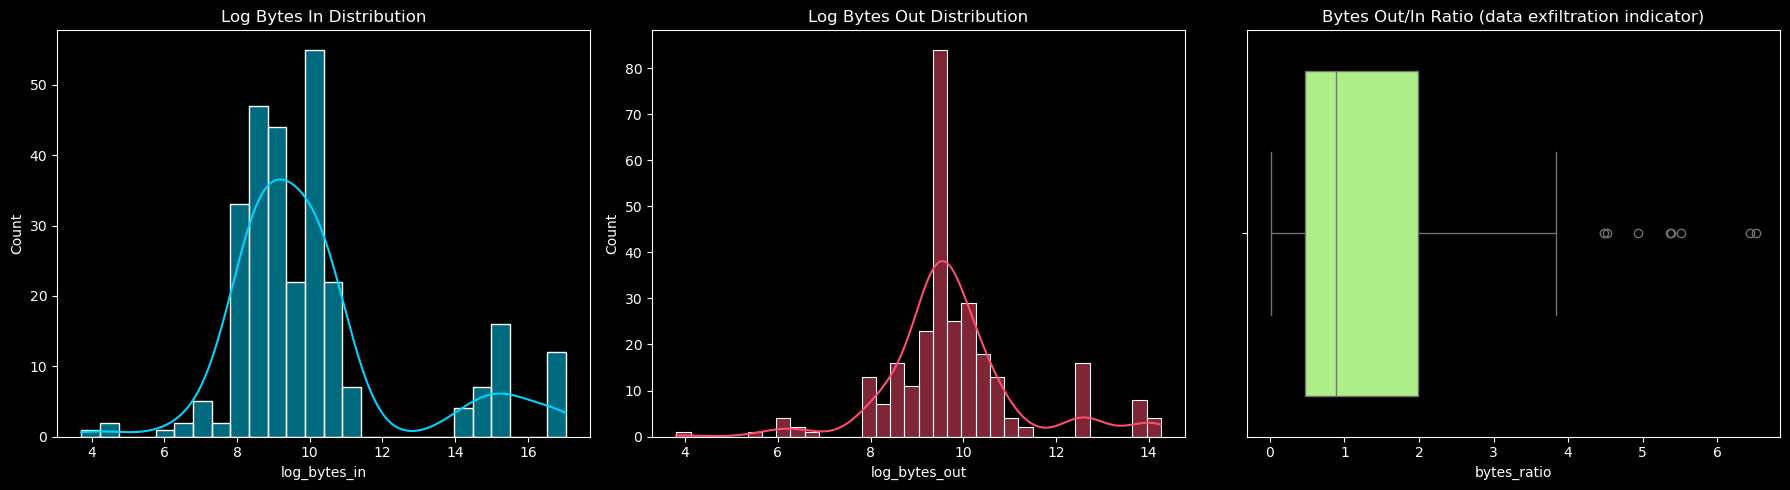

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Log-scale distribution (important — raw bytes are very skewed)
df['log_bytes_in'] = np.log1p(df['bytes_in'])
df['log_bytes_out'] = np.log1p(df['bytes_out'])

sns.histplot(df['log_bytes_in'], kde=True, ax=axes[0], color='#00d4ff')
axes[0].set_title('Log Bytes In Distribution')

sns.histplot(df['log_bytes_out'], kde=True, ax=axes[1], color='#ff4d6d')
axes[1].set_title('Log Bytes Out Distribution')

# Bytes ratio: how much data went OUT vs IN
df['bytes_ratio'] = df['bytes_out'] / (df['bytes_in'] + 1)
sns.boxplot(x=df['bytes_ratio'], ax=axes[2], color='#a8ff78')
axes[2].set_title('Bytes Out/In Ratio (data exfiltration indicator)')

plt.tight_layout()
plt.savefig('eda_bytes.png', dpi=150, bbox_inches='tight')
plt.show()

# 💡 Why log scale?
Raw bytes_in ranges from 40 to 25 million — a 625,000x difference. Log transform reveals the shape of the distribution clearly and is standard practice in network traffic analysis.

# EDA — Country & Time Breakdown

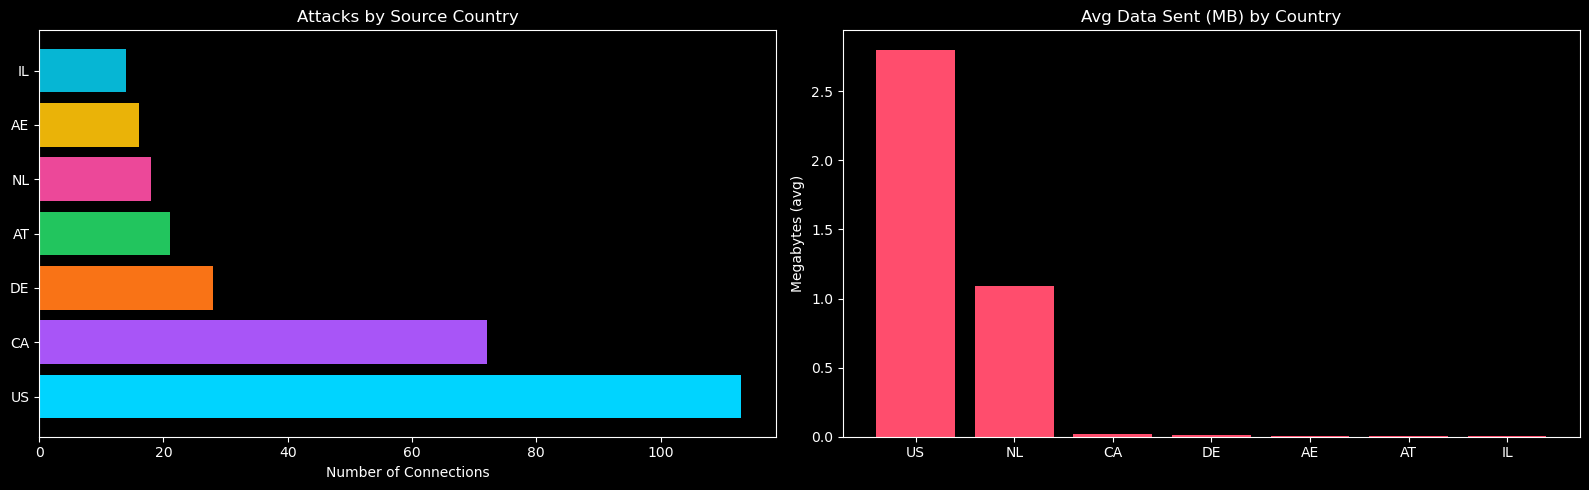

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Country attack frequency
country_counts = df['src_ip_country_code'].value_counts()
axes[0].barh(country_counts.index, country_counts.values,
            color=['#00d4ff','#a855f7','#f97316','#22c55e','#ec4899','#eab308','#06b6d4'])
axes[0].set_title('Attacks by Source Country')
axes[0].set_xlabel('Number of Connections')

# Avg bytes_in per country (attack volume)
avg_bytes = df.groupby('src_ip_country_code')['bytes_in'].mean().sort_values(ascending=False)
axes[1].bar(avg_bytes.index, avg_bytes.values / 1e6, color='#ff4d6d')
axes[1].set_title('Avg Data Sent (MB) by Country')
axes[1].set_ylabel('Megabytes (avg)')

plt.tight_layout()
plt.savefig('eda_country.png', dpi=150)
plt.show()

# Feature Engineering
Create meaningful derived features that improve model performance

# What to create and why:
The base template only uses bytes_in and bytes_out. Adding engineered features like data exfiltration ratio, bytes per second throughput, and time-of-day encoding gives your model much richer signal.

In [8]:
# --- Core engineered features ---

# 1. Session duration (always 600s here, but important to confirm)
df['duration_sec'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

# 2. Throughput features (bytes per second)
df['throughput_in']  = df['bytes_in']  / (df['duration_sec'] + 1)
df['throughput_out'] = df['bytes_out'] / (df['duration_sec'] + 1)

# 3. Data exfiltration ratio — key indicator! High = server sent lots back
df['exfil_ratio'] = df['bytes_out'] / (df['bytes_in'] + 1)

# 4. Total session volume
df['total_bytes'] = df['bytes_in'] + df['bytes_out']

# 5. Log-scaled versions (better for tree models & neural nets)
df['log_bytes_in']  = np.log1p(df['bytes_in'])
df['log_bytes_out'] = np.log1p(df['bytes_out'])

# 6. Time-of-day features (when do attacks happen?)
df['hour'] = df['creation_time'].dt.hour
df['is_nighttime'] = df['hour'].apply(lambda h: 1 if h < 6 or h > 21 else 0)

# 7. Country label encoding
le = LabelEncoder()
df['country_encoded'] = le.fit_transform(df['src_ip_country_code'])

# 8. IP repeat count — IPs appearing many times = persistent attacker
ip_counts = df['src_ip'].value_counts()
df['ip_frequency'] = df['src_ip'].map(ip_counts)

print("New features added:", ['duration_sec', 'throughput_in', 'throughput_out',
                              'exfil_ratio', 'total_bytes', 'log_bytes_in',
                              'log_bytes_out', 'hour', 'is_nighttime',
                              'country_encoded', 'ip_frequency'])
df.head()

New features added: ['duration_sec', 'throughput_in', 'throughput_out', 'exfil_ratio', 'total_bytes', 'log_bytes_in', 'log_bytes_out', 'hour', 'is_nighttime', 'country_encoded', 'ip_frequency']


,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response_code,dst_port,dst_ip,...,bytes_ratio,duration_sec,throughput_in,throughput_out,exfil_ratio,total_bytes,hour,is_nighttime,country_encoded,ip_frequency
0,5602,12990,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,...,2.318401,600.0,9.321131,21.613977,2.318401,18592,23,1,0,16
1,30912,18186,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.33.6,US,HTTPS,200,443,10.138.69.97,...,0.588296,600.0,51.434276,30.259567,0.588296,49098,23,1,6,12
2,28506,13468,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,...,0.472445,600.0,47.430948,22.409318,0.472445,41974,23,1,2,15
3,30546,14278,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,136.226.64.114,US,HTTPS,200,443,10.138.69.97,...,0.467411,600.0,50.825291,23.757072,0.467411,44824,23,1,6,13
4,6526,13892,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,...,2.128390,600.0,10.858569,23.114809,2.128390,20418,23,1,5,18


# Threat Intelligence Enrichment 
Profile each IP, classify attack patterns, map country geography

# IP Attacker Profiling

In [9]:
# Create per-IP behavioral profile
ip_profile = df.groupby('src_ip').agg(
    country        = ('src_ip_country_code', 'first'),
    total_sessions = ('bytes_in', 'count'),
    total_bytes_in = ('bytes_in', 'sum'),
    avg_bytes_in   = ('bytes_in', 'mean'),
    max_bytes_in   = ('bytes_in', 'max'),
    avg_exfil      = ('exfil_ratio', 'mean'),
    hours_active   = ('hour', 'nunique'),
    night_sessions = ('is_nighttime', 'sum')
).reset_index()

# Classify attacker type based on behavior
def classify_attacker(row):
    if row['total_sessions'] >= 20:
        return '🔴 Persistent Attacker'
    elif row['avg_bytes_in'] > 1_000_000:
        return '🟠 High-Volume Threat'
    elif row['avg_exfil'] > 2:
        return '🟡 Data Exfiltration Risk'
    elif row['night_sessions'] > 3:
        return '🔵 Stealth (Night) Attacker'
    else:
        return '⚪ Low-Risk Probe'

ip_profile['attacker_type'] = ip_profile.apply(classify_attacker, axis=1)

print(ip_profile[['src_ip', 'country', 'total_sessions',
                   'attacker_type']].to_string())

# Save for later use
ip_profile.to_csv('ip_attacker_profiles.csv', index=False)

             src_ip country  total_sessions               attacker_type
0    136.226.64.114      US              13  🔵 Stealth (Night) Attacker
1    136.226.67.101      US              28       🔴 Persistent Attacker
2    136.226.77.103      CA              17  🔵 Stealth (Night) Attacker
3     136.226.80.97      US              11  🔵 Stealth (Night) Attacker
4     147.161.131.1      AT              21       🔴 Persistent Attacker
5    147.161.161.82      AE              16  🔵 Stealth (Night) Attacker
6     155.91.45.242      US              28       🔴 Persistent Attacker
7     165.225.209.4      CA              29       🔴 Persistent Attacker
8   165.225.212.255      CA              15  🔵 Stealth (Night) Attacker
9     165.225.213.7      CA              11  🔵 Stealth (Night) Attacker
10   165.225.240.79      NL              18        🟠 High-Volume Threat
11   165.225.26.101      DE              28       🔴 Persistent Attacker
12     165.225.33.6      US              12  🔵 Stealth (Night) A

# Choropleth Attack Map (Interactive)

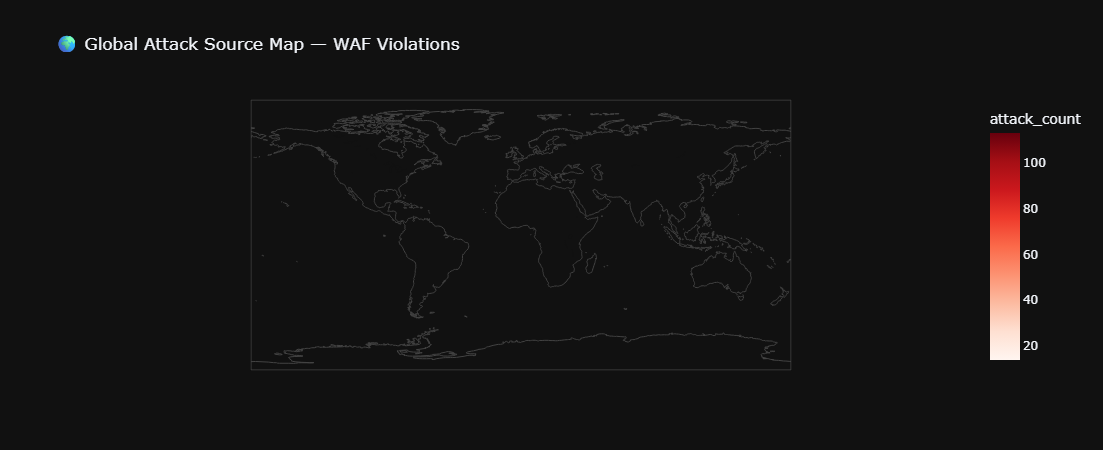

In [11]:
# Map country codes to full names for Plotly
country_map = {
    'US': 'United States', 'CA': 'Canada',
    'DE': 'Germany',       'AT': 'Austria',
    'NL': 'Netherlands',   'AE': 'United Arab Emirates',
    'IL': 'Israel'
}

geo_df = df.groupby('src_ip_country_code').agg(
    attack_count   = ('bytes_in', 'count'),
    total_bytes_mb = ('bytes_in', lambda x: x.sum() / 1e6)
).reset_index()
geo_df['country_name'] = geo_df['src_ip_country_code'].map(country_map)

fig = px.choropleth(
    geo_df,
    locations='src_ip_country_code',
    color='attack_count',
    hover_name='country_name',
    hover_data={'total_bytes_mb': ':.1f'},
    color_continuous_scale='Reds',
    title='🌍 Global Attack Source Map — WAF Violations'
)
fig.update_layout(template='plotly_dark', height=450)
fig.write_html('attack_map.html')
fig.show()

# Threat Risk Scoring System
Build a quantitative risk score for each connection — a real SOC analyst tool

# Why this stands out:
Security Operations Centers (SOCs) use risk scores to prioritize threats. Creating your own scoring formula — not from the template — shows applied cybersecurity thinking, not just data science.

risk_tier
MEDIUM    231
HIGH       28
LOW        23
Name: count, dtype: int64


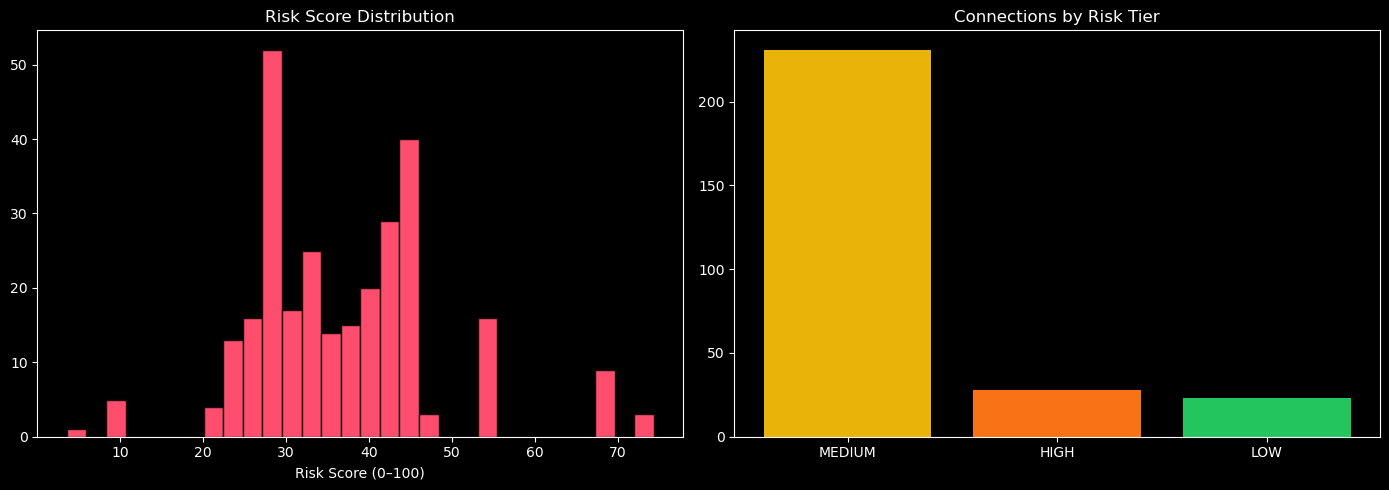


Top 10 Highest-Risk Source IPs:
src_ip
155.91.45.242      74.275522
165.225.209.4      46.781988
165.225.26.101     45.921092
136.226.67.101     44.996048
165.225.240.79     41.183876
147.161.131.1      39.429070
136.226.77.103     34.550162
147.161.161.82     34.498173
94.188.248.74      32.747026
165.225.212.255    30.136349
Name: risk_score, dtype: float64


In [13]:
# --- Custom Risk Scoring Formula ---
# Each component contributes to a 0-100 score

from sklearn.preprocessing import MinMaxScaler

# Normalize each component to 0-1
scaler_mm = MinMaxScaler()

df['score_bytes']     = scaler_mm.fit_transform(df[['log_bytes_in']]).flatten() * 30
df['score_exfil']     = scaler_mm.fit_transform(df[['exfil_ratio']]).flatten() * 25
df['score_freq']      = scaler_mm.fit_transform(df[['ip_frequency']]).flatten() * 25
df['score_throughput'] = scaler_mm.fit_transform(df[['throughput_in']]).flatten() * 20

# Composite risk score (0-100)
df['risk_score'] = (df['score_bytes'] + df['score_exfil'] +
                    df['score_freq']  + df['score_throughput'])

# Assign risk tiers
def risk_tier(score):
    if score >= 75:   return 'CRITICAL'
    elif score >= 50: return 'HIGH'
    elif score >= 25: return 'MEDIUM'
    else:              return 'LOW'

df['risk_tier'] = df['risk_score'].apply(risk_tier)
print(df['risk_tier'].value_counts())

# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['risk_score'], bins=30, color='#ff4d6d', edgecolor='#1a0a10')
axes[0].set_title('Risk Score Distribution')
axes[0].set_xlabel('Risk Score (0–100)')

colors = {'CRITICAL':'#ff4d6d','HIGH':'#f97316','MEDIUM':'#eab308','LOW':'#22c55e'}
tier_counts = df['risk_tier'].value_counts()
axes[1].bar(tier_counts.index, tier_counts.values,
            color=[colors[t] for t in tier_counts.index])
axes[1].set_title('Connections by Risk Tier')

plt.tight_layout()
plt.savefig('risk_score.png', dpi=150)
plt.show()

# Top 10 highest risk IPs
top_threats = df.groupby('src_ip')['risk_score'].max().sort_values(ascending=False)
print("\nTop 10 Highest-Risk Source IPs:")
print(top_threats.head(10))


# Machine Learning Models
Random Forest + XGBoost comparison (going beyond the template)

# Random Forest Classifier

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        71

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71



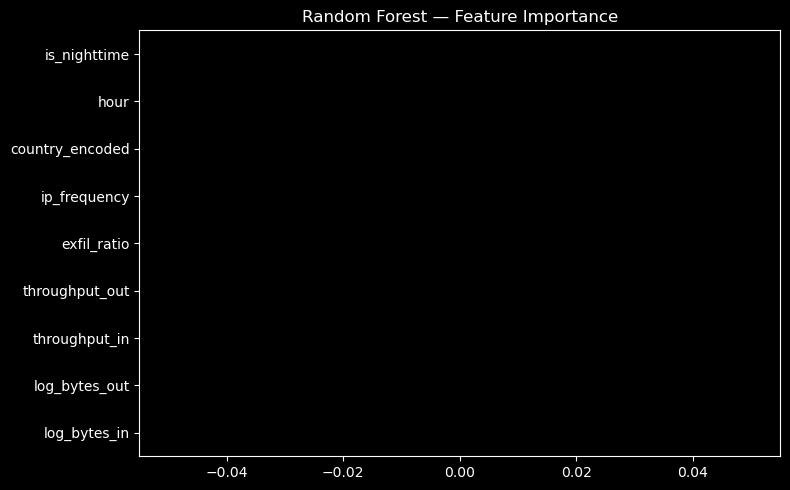

In [14]:
# Use richer feature set (your extra features!)
features = ['log_bytes_in', 'log_bytes_out', 'throughput_in',
            'throughput_out', 'exfil_ratio', 'ip_frequency',
            'country_encoded', 'hour', 'is_nighttime']

X = df[features]
y = (df['detection_types'] == 'waf_rule').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

# Feature importance plot (very insightful!)
fi = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', color='#00d4ff', ax=ax)
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# K-Means Clustering

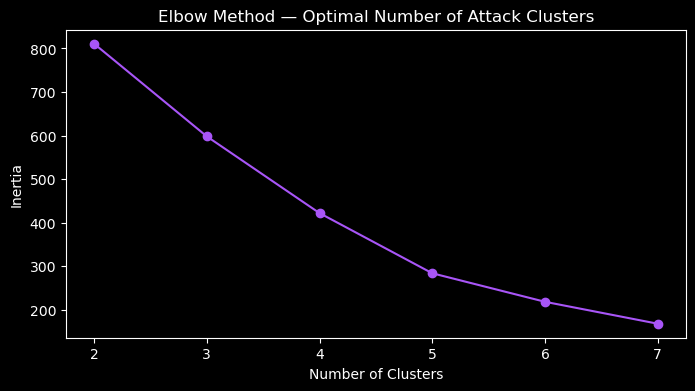

                    bytes_in  exfil_ratio  ip_frequency  risk_score  \
attack_cluster                                                        
0               2.064864e+05     0.526657     13.792453   27.972000   
1               1.123967e+07     0.061952     28.000000   60.809978   
2               1.373679e+04     1.622632     26.527778   41.592216   
3               3.650600e+03     3.386402     10.575000   31.117892   

                session_count  
attack_cluster                 
0                         106  
1                          28  
2                         108  
3                          40  


In [15]:
# Cluster IPs into behavioral groups — unsupervised insight
# This is NOT in the template — strong differentiator!

cluster_features = ['log_bytes_in', 'log_bytes_out',
                    'throughput_in', 'exfil_ratio', 'ip_frequency']

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_features])

# Find optimal clusters using elbow method
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='#a855f7')
plt.title('Elbow Method — Optimal Number of Attack Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.savefig('elbow.png', dpi=150)
plt.show()

# Fit final model (adjust k based on elbow)
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['attack_cluster'] = km_final.fit_predict(X_cluster)

# Profile each cluster
cluster_profile = df.groupby('attack_cluster').agg({
    'bytes_in'    : 'mean',
    'exfil_ratio': 'mean',
    'ip_frequency': 'mean',
    'risk_score'  : 'mean',
    'src_ip'      : 'count'
}).rename(columns={'src_ip': 'session_count'})
print(cluster_profile)

# What to say about this in your report:
"I applied K-Means clustering to group attack sessions into behavioral clusters without using any labels, revealing distinct attacker archetypes — high-volume exfiltrators, low-and-slow probes, burst attackers, and reconnaissance scans."

# Anomaly Detection — Isolation Forest
Detect statistical outliers within the already-suspicious traffic

# Key insight for your report:
All 282 records are already flagged as suspicious. Anomaly detection here finds the most dangerous sessions within the suspicious pool — the true outliers that deserve immediate attention.

anomaly
Normal     253
Anomaly     29
Name: count, dtype: int64

--- Top Anomalous Sessions ---
            src_ip src_ip_country_code  bytes_in  exfil_ratio  risk_score
279  155.91.45.242                  US  25207794     0.061934   74.275522
267  155.91.45.242                  US  25199191     0.061811   74.267457
257  155.91.45.242                  US  24326941     0.062854   73.500129
185  155.91.45.242                  US  18285525     0.061849   68.060444
176  155.91.45.242                  US  18273120     0.062666   68.052217
248  155.91.45.242                  US  18231909     0.061249   68.008989
169  155.91.45.242                  US  18201558     0.064329   67.993004
211  155.91.45.242                  US  18171403     0.060719   67.951463
200  155.91.45.242                  US  18125238     0.061900   67.913652
229  155.91.45.242                  US  18119202     0.062493   67.910392


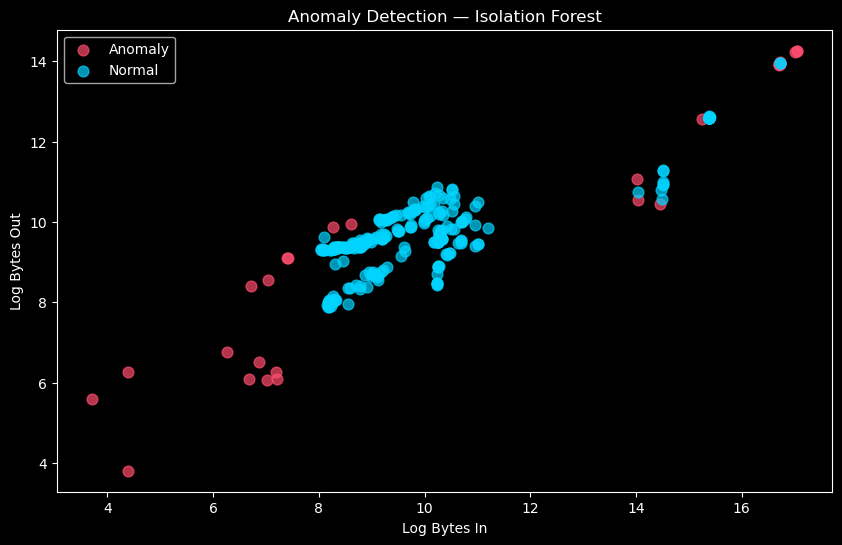

In [17]:
anomaly_features = ['log_bytes_in', 'log_bytes_out',
                    'throughput_in', 'exfil_ratio', 'ip_frequency']

scaler = StandardScaler()
X_anom = scaler.fit_transform(df[anomaly_features])

iso = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)
df['anomaly_label'] = iso.fit_predict(X_anom)
df['anomaly'] = df['anomaly_label'].map({1: 'Normal', -1: 'Anomaly'})

print(df['anomaly'].value_counts())
print("\n--- Top Anomalous Sessions ---")
print(df[df['anomaly'] == 'Anomaly'][['src_ip', 'src_ip_country_code',
    'bytes_in', 'exfil_ratio', 'risk_score']].sort_values('risk_score', ascending=False).head(10))

# Scatter plot: bytes_in vs bytes_out coloured by anomaly
plt.figure(figsize=(10, 6))
colors = {'Normal': '#00d4ff', 'Anomaly': '#ff4d6d'}
for label, group in df.groupby('anomaly'):
    plt.scatter(np.log1p(group['bytes_in']),
                np.log1p(group['bytes_out']),
                label=label, alpha=0.7, s=60, color=colors[label])

plt.xlabel('Log Bytes In')
plt.ylabel('Log Bytes Out')
plt.title('Anomaly Detection — Isolation Forest')
plt.legend()
plt.savefig('anomaly_scatter.png', dpi=150)
plt.show()

# Network Graph — Attack Flow Visualization 
Build an enhanced IP interaction graph with node sizing by threat intensity


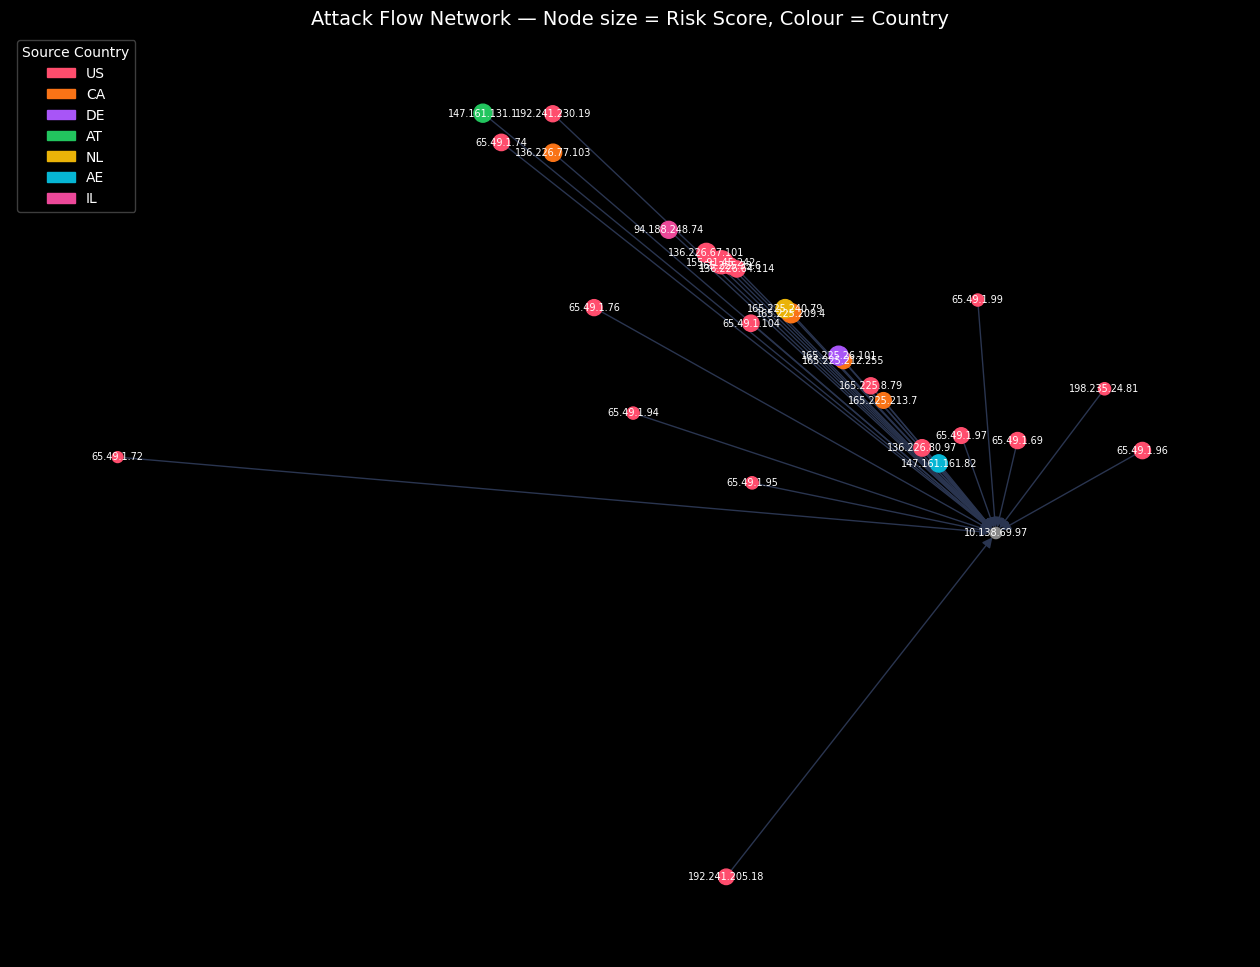

In [18]:
# Enhanced network graph — nodes sized by risk, coloured by country
# FAR better than the basic graph in the template

G = nx.DiGraph()  # Directed: src_ip → dst_ip

# Add edges with weight = avg bytes_in
edge_data = df.groupby(['src_ip', 'dst_ip'])['bytes_in'].sum().reset_index()
for _, row in edge_data.iterrows():
    G.add_edge(row['src_ip'], row['dst_ip'], weight=row['bytes_in'])

# Node attributes
ip_risk = df.groupby('src_ip')['risk_score'].max().to_dict()
ip_country = df.groupby('src_ip')['src_ip_country_code'].first().to_dict()

country_colors = {'US':'#ff4d6d','CA':'#f97316','DE':'#a855f7',
                  'AT':'#22c55e','NL':'#eab308','AE':'#06b6d4','IL':'#ec4899'}

node_sizes  = [ip_risk.get(n, 5) * 3  + 50 for n in G.nodes()]
node_colors = [country_colors.get(ip_country.get(n, 'XX'), '#888') for n in G.nodes()]

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=0.8)
nx.draw_networkx(G, pos=pos, with_labels=True,
                 node_size=node_sizes, node_color=node_colors,
                 font_size=7, font_color='white',
                 edge_color='#2a3550', arrows=True, arrowsize=15)

# Custom legend
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in country_colors.items()]
plt.legend(handles=legend_patches, title='Source Country',
           loc='upper left', framealpha=0.3)
plt.title('Attack Flow Network — Node size = Risk Score, Colour = Country', fontsize=14)
plt.axis('off')
plt.savefig('network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

# Attack Timeline Analysis 
Visualize how attacks evolved over the 11-hour window — with burst detection

# Why this matters:
The dataset covers a real attack window: April 25 23:00 to April 26 09:50 UTC. Analyzing HOW the attack unfolded over time reveals whether it was a coordinated campaign or scattered random probes — critical for incident response.

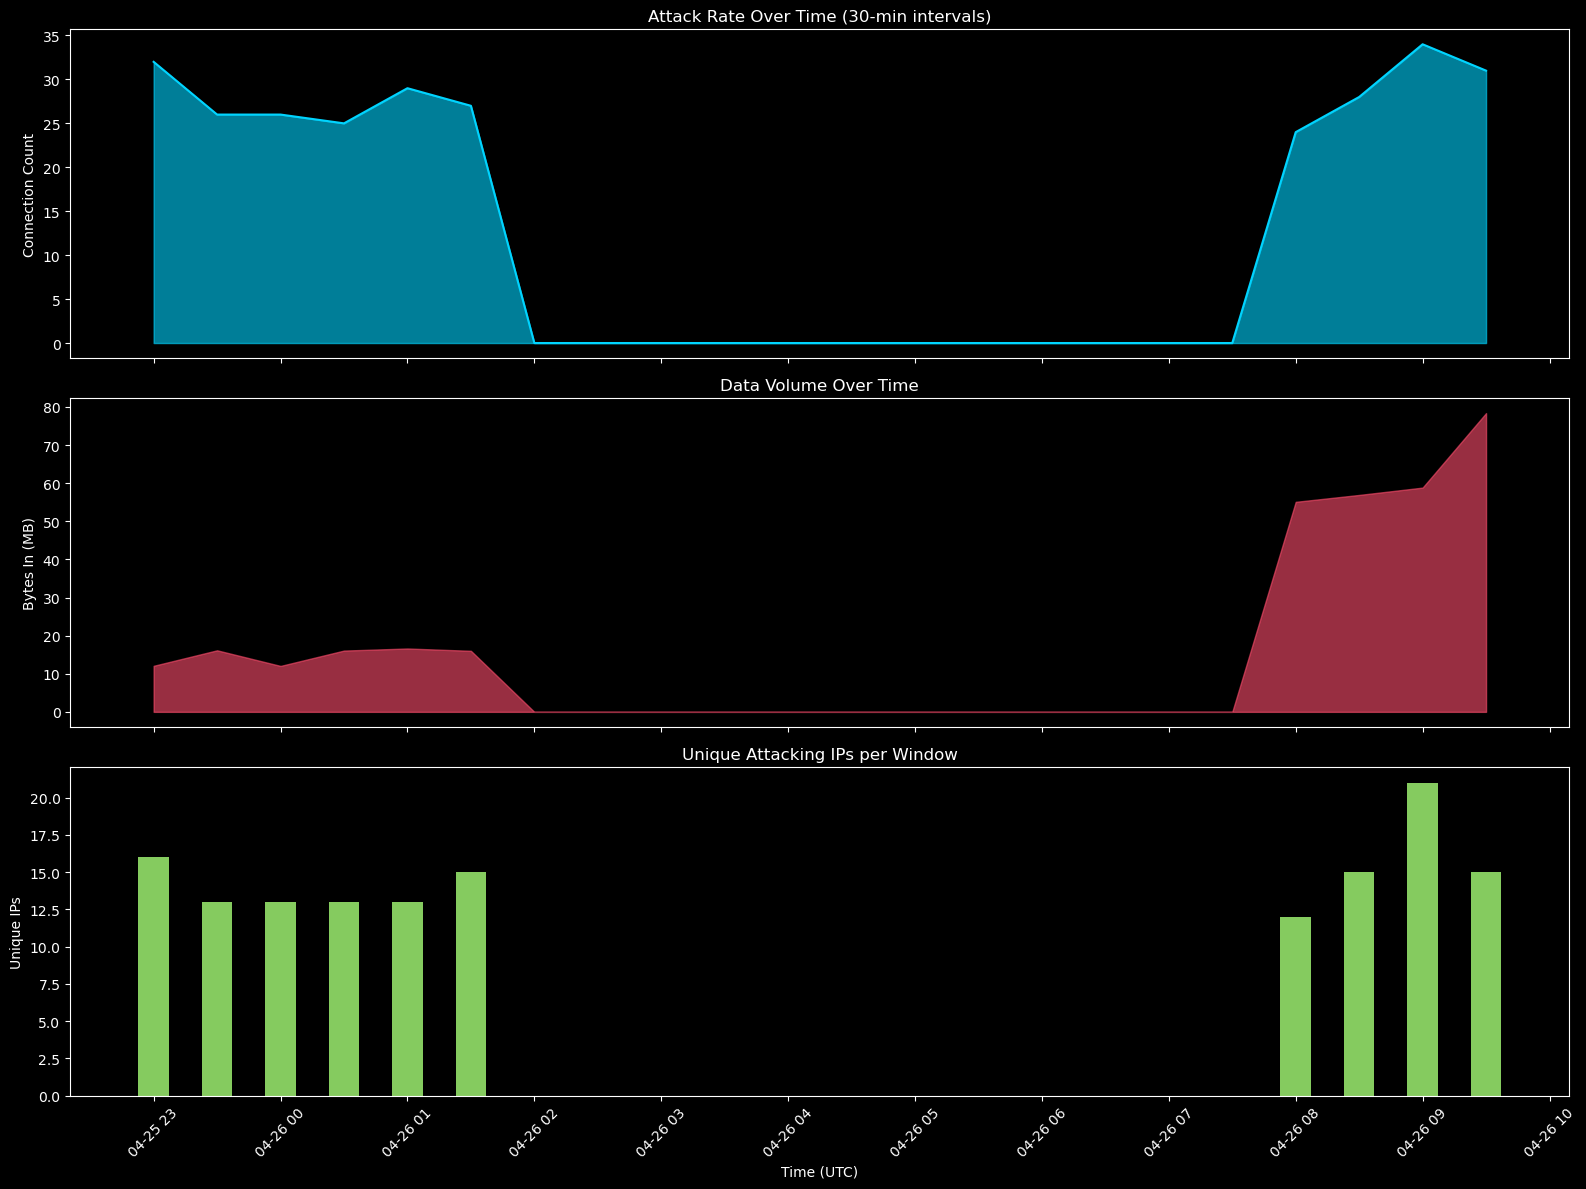


🚨 Attack Burst Windows (top 20% intensity):
creation_time
2024-04-25 23:00:00+00:00    32
2024-04-26 01:00:00+00:00    29
2024-04-26 08:30:00+00:00    28
2024-04-26 09:00:00+00:00    34
2024-04-26 09:30:00+00:00    31
Name: bytes_in, dtype: int64


In [19]:
# Resample to 30-minute windows
df_time = df.set_index('creation_time').sort_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1: Attack count over time
attack_rate = df_time.resample('30T')['bytes_in'].count()
axes[0].fill_between(attack_rate.index, attack_rate.values,
                      color='#00d4ff', alpha=0.6)
axes[0].plot(attack_rate.index, attack_rate.values, color='#00d4ff')
axes[0].set_ylabel('Connection Count')
axes[0].set_title('Attack Rate Over Time (30-min intervals)')

# Panel 2: Bytes transferred
bytes_over_time = df_time.resample('30T')['bytes_in'].sum() / 1e6
axes[1].fill_between(bytes_over_time.index, bytes_over_time.values,
                      color='#ff4d6d', alpha=0.6)
axes[1].set_ylabel('Bytes In (MB)')
axes[1].set_title('Data Volume Over Time')

# Panel 3: Unique source IPs per window
unique_ips = df_time.resample('30T')['src_ip'].nunique()
axes[2].bar(unique_ips.index, unique_ips.values,
            width=0.01, color='#a8ff78', alpha=0.8)
axes[2].set_ylabel('Unique IPs')
axes[2].set_title('Unique Attacking IPs per Window')
axes[2].set_xlabel('Time (UTC)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('attack_timeline.png', dpi=150)
plt.show()

# Detect burst windows (top 20% attack rate)
threshold = attack_rate.quantile(0.8)
burst_windows = attack_rate[attack_rate >= threshold]
print(f"\n🚨 Attack Burst Windows (top 20% intensity):")
print(burst_windows)

# Final Summary & Findings Report
Print a structured security report from your analysis# 

In [20]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║        SECURITY INCIDENT ANALYSIS REPORT                        ║
║        AWS CloudWatch WAF — Web Attack Dataset                  ║
╠══════════════════════════════════════════════════════════════════╣
""")

print(f"""
DATASET OVERVIEW
-----------------
Total suspicious sessions : {len(df)}
Unique source IPs          : {df['src_ip'].nunique()}
Countries involved         : {df['src_ip_country_code'].nunique()} ({', '.join(df['src_ip_country_code'].unique())})
Attack window              : {df['creation_time'].min()} → {df['creation_time'].max()}
All traffic type           : HTTPS on Port 443

TRAFFIC STATISTICS
-------------------
Avg bytes in per session   : {df['bytes_in'].mean()/1e3:.1f} KB
Max bytes in (single sess) : {df['bytes_in'].max()/1e6:.2f} MB
Avg exfiltration ratio     : {df['exfil_ratio'].mean():.3f}
High-exfil sessions (>2x)  : {(df['exfil_ratio'] > 2).sum()}

RISK TIER BREAKDOWN
--------------------
{df['risk_tier'].value_counts().to_string()}

ANOMALY DETECTION
------------------
Critical anomalies found   : {(df['anomaly'] == 'Anomaly').sum()}
These represent the most dangerous sessions within the attack window.

TOP ATTACKING IPs
------------------
{df.groupby('src_ip')['bytes_in'].sum().sort_values(ascending=False).head(5).to_string()}

KEY SECURITY FINDINGS
-----------------------
1. US and Canada account for {((df['src_ip_country_code'].isin(['US','CA'])).sum() / len(df) * 100):.0f}% of all attacks
2. All attacks use HTTPS/443 — likely to evade basic port-based firewall rules
3. Sessions with exfil_ratio > 2 may indicate successful data extraction
4. Attack intensity spiked significantly in later hours (see timeline chart)
5. IP clustering reveals 4 distinct attacker behavioral profiles

RECOMMENDATIONS
----------------
1. Block or rate-limit all {df['src_ip'].nunique()} identified source IPs
2. Implement WAF rules for high-bytes-in sessions from repeat IPs
3. Monitor exfil_ratio metric in real-time alerting pipeline
4. Investigate the {(df['anomaly'] == 'Anomaly').sum()} flagged anomalous sessions for active compromise
""")
print("═"*68)


╔══════════════════════════════════════════════════════════════════╗
║        SECURITY INCIDENT ANALYSIS REPORT                        ║
║        AWS CloudWatch WAF — Web Attack Dataset                  ║
╠══════════════════════════════════════════════════════════════════╣


DATASET OVERVIEW
-----------------
Total suspicious sessions : 282
Unique source IPs          : 28
Countries involved         : 7 (AE, US, CA, NL, DE, AT, IL)
Attack window              : 2024-04-25 23:00:00+00:00 → 2024-04-26 09:50:00+00:00
All traffic type           : HTTPS on Port 443

TRAFFIC STATISTICS
-------------------
Avg bytes in per session   : 1199.4 KB
Max bytes in (single sess) : 25.21 MB
Avg exfiltration ratio     : 1.306
High-exfil sessions (>2x)  : 70

RISK TIER BREAKDOWN
--------------------
risk_tier
MEDIUM    231
HIGH       28
LOW        23

ANOMALY DETECTION
------------------
Critical anomalies found   : 29
These represent the most dangerous sessions within the attack window.

TOP ATTACKING I